In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
def graph(xrange, supply_slope, demand_slope, supply_int, demand_int, ceil=False, floor=False, world=False, tariff=False):
    if (ceil is not False) and (floor is not False): return "Incompatible Parameters"
    if (ceil is not False) and (world is not False): return "Incompatible Parameters" 
    if (ceil is not False) and (tariff is not False): return "Incompatible Parameters"
    if (floor is not False) and (world is not False): return "Incompatible Parameters"
    if (floor is not False) and (tariff is not False): return "Incompatible Parameters"
    if (tariff is not False) and (world is False): return "Cannot have tariff without world price"
    if (world is not False) and (tariff is not False) and (world > tariff): return "Tariff cannot be less than the world price"
    quantity = np.linspace(0, xrange, 500)
    price_S = supply_slope * quantity + supply_int
    price_D = demand_slope * quantity + demand_int
    equilibrium_quant = (supply_int - demand_int) / (demand_slope - supply_slope)
    equilibrium_price = supply_slope * equilibrium_quant + supply_int
    if (world is not False) and (world > equilibrium_price) and (tariff is not False): return "Incompatible Parameters"
    if (ceil is not False) and (ceil > equilibrium_price): return "Ceiling price cannot be above equilibrium price"
    if (floor is not False) and (floor < equilibrium_price): return "Floor price cannot be below equilibrium price"
    print(f"Price (Supply) = {supply_slope}Q + {supply_int}")
    print(f"Price (Demand) = {demand_slope}Q + {demand_int}")
    print(f"Quantity (Supply) = (P - {supply_int}) / {supply_slope}")
    print(f"Quantity (Demand) = (P - {demand_int}) / {demand_slope}")
    print(f"Equilibrium Quantity: {equilibrium_quant}")
    print(f"Equilibrium Price: {equilibrium_price}")
    plt.plot(quantity, price_D, label="Demand", color="Red")
    plt.plot(quantity, price_S, label="Supply", color="Blue")
    plt.xlabel("Quantity")
    plt.ylabel("Price")
    plt.xlim(0, None)
    plt.ylim(0, None)
    if ceil is not False:
     plt.axhline(y=ceil, color="Black", label = "Price Ceiling")
     ceil_supply = (ceil - supply_int) / supply_slope
     ceil_demand = (ceil - demand_int) / demand_slope
     shortage_Q = demand_slope * ceil_supply + demand_int
     plt.axvline(x=ceil_supply, linestyle="--", color="black")
     plt.axvline(x=ceil_demand, linestyle="--", color="black")
     plt.title("Supply vs Demand, Price Ceiling")
     plt.fill_between(quantity[quantity <= ceil_supply], price_S[quantity <= ceil_supply], ceil, color="green", label="Producer Surplus")
     plt.fill_between(quantity[quantity <= ceil_supply], price_D[quantity <= ceil_supply], ceil, color='blue', label="Consumer Surplus")
     plt.fill_between(quantity, price_S, price_D, where=(price_D >= price_S) & (quantity >= ceil_supply), color='Black', label="Deadweight Loss")
     ps = (ceil - supply_int) * (ceil_supply) * 0.5
     cs = ((shortage_Q - ceil) * (ceil_supply)) + ((demand_int - shortage_Q) * (ceil_supply) * 0.5)
     gft = cs + ps
     shortage = ceil_demand - ceil_supply
     dwl = (shortage_Q - ceil) * (equilibrium_quant - ceil_supply) * 0.5
     print(f"Shortage: {shortage}")
     print(f"Consumer Surplus: {cs}")
     print(f"Producer Surplus: {ps}")
     print(f"Gains From Trade: {gft}")
     print(f"Deadweight Loss: {dwl}")


    elif floor is not False:
     plt.axhline(y=floor, color="Black", label = "Price Floor")
     floor_supply = (floor - supply_int) / supply_slope 
     floor_demand = (floor - demand_int) / demand_slope
     surplus_Q = supply_slope * floor_demand + supply_int
     plt.axvline(x=floor_supply, linestyle="--", color="black")
     plt.axvline(x=floor_demand, linestyle="--", color="black")
     plt.title("Supply vs Demand, Price Floor")
     plt.fill_between(quantity[quantity <= floor_demand], price_D[quantity <= floor_demand], floor, color="blue")
     plt.fill_between(quantity[quantity <= floor_demand], price_S[quantity <= floor_demand], floor, color="green")
     plt.fill_between(quantity, price_S, price_D, where=(price_D >= price_S) & (quantity >= floor_demand), color='Black', label="Deadwieght Loss")


     cs = (demand_int - floor) * (floor_demand) * 0.5
     ps = ((floor - surplus_Q) * (floor_demand)) + ((surplus_Q - supply_int) * (floor_demand) * 0.5)
     gft = cs + ps
     surplus = floor_supply - floor_demand
     dwl = (floor - surplus_Q) * (equilibrium_quant - floor_demand) * 0.5 
     print(f"Surplus: {surplus}")
     print(f"Consumer Surplus: {cs}")
     print(f"Producer Surplus: {ps}")
     print(f"Gains From Trade: {gft}")
     print(f"Deadweight Loss: {dwl}")
    
    elif (world is not False) and (world < equilibrium_price):
      if tariff is not False:
        plt.axhline(y=tariff, color="Purple", label = "Tariff")
        plt.axhline(y=world, color="Black", label = "World Price")
        tariff_demand = (tariff - demand_int) / demand_slope
        tariff_supply = (tariff - supply_int) / supply_slope 
        import_supply = (world - supply_int) / supply_slope 
        import_demand = (world - demand_int) / demand_slope
        plt.axvline(x=tariff_demand, linestyle="--", color="black")
        plt.axvline(x=tariff_supply, linestyle="--", color="black")
        plt.axvline(x=import_demand, linestyle="--", color="black")
        plt.axvline(x=import_supply, linestyle="--", color="black")
        plt.title("Supply vs Demand, Trade with Tariff")
        cs = (demand_int - tariff) * (tariff_demand) * 0.5
        ps = (tariff - supply_int) * (tariff_supply) * 0.5
        ge = (tariff - world) * (tariff_demand - tariff_supply)
        dwl_left = (tariff - world) * (tariff_supply - import_supply) * 0.5
        dwl_right = (tariff - world) * (import_demand - tariff_demand) * 0.5
        dwl = dwl_left + dwl_right
        gft = ps + cs + ge
        plt.fill_between(quantity, price_D, tariff, where=(price_D >= tariff), color='blue', label="Consumer Surplus")
        plt.fill_between(quantity, price_S, tariff, where=(price_S <= tariff), color='green', label = "Producer Surplus")
        plt.fill_between(quantity[(quantity >= tariff_supply) & (quantity <= tariff_demand)], world, tariff, color="yellow", label="Government Revenue")        
        plt.fill_between(quantity[(quantity >= import_supply) & (quantity <= tariff_supply)], price_S[(quantity >= import_supply) & (quantity <= tariff_supply)], world, color="black", label="Deadweight Loss")      
        plt.fill_between(quantity[(quantity >= tariff_demand) & (quantity <= import_demand)], world, price_D[(quantity >= tariff_demand) & (quantity <= import_demand)], color="black")
        print(f"Amount Imported: {(import_demand - import_supply)}")
        print(f"Consumer Surplus: {cs}")
        print(f"Producer Surplus: {ps}")
        print(f"Government Revenue: {ge}")
        print(f"Gains From Trade: {gft}")
        print(f"Deadweight Loss: {dwl}")
      else: 
        plt.axhline(y=world, color="Black", label = "World Price")
        plt.title("Supply vs Demand, Trade with Imports")
        import_demand = (world - demand_int) / demand_slope
        import_supply = (world - supply_int) / supply_slope 
        plt.fill_between(quantity, price_D, world, where=(price_D >= world), color='blue', label="Consumer Surplus")
        plt.fill_between(quantity, price_S, world, where=(price_S <= world), color='green', label = "Producer Surplus")
        cs = (demand_int - world) * (import_demand) * 0.5
        ps = (world - supply_int) * (import_supply) * 0.5
        gft = cs + ps
        print(f"Amount Imported: {(import_demand - import_supply)}")
        print(f"Consumer Surplus: {cs}")
        print(f"Producer Surplus: {ps}")
        print(f"Gains From Trade: {gft}")
    elif (world is not False) and (world > equilibrium_price):
      plt.title("Supply vs Demand, Trade with Exports")
      plt.axhline(y=world, color="Black", label = "World Price")
      import_demand = (world - demand_int) / demand_slope
      import_supply = (world - supply_int) / supply_slope 
      plt.fill_between(quantity, price_D, world, where=(price_D >= world), color='blue', label="Consumer Surplus")
      plt.fill_between(quantity, price_S, world, where=(price_S <= world), color='green', label = "Producer Surplus")
      cs = (demand_int - world) * (import_demand) * 0.5
      ps = (world - supply_int) * (import_supply) * 0.5
      gft = cs + ps
      print(f"Amount Imported: {(import_demand - import_supply)}")
      print(f"Consumer Surplus: {cs}")
      print(f"Producer Surplus: {ps}")
      print(f"Gains From Trade: {gft}")
    else:
      plt.title("Supply vs Demand, Autarky")
      cs = (demand_int - equilibrium_price) * (equilibrium_quant) * 0.5
      ps = (equilibrium_price - supply_int) * (equilibrium_quant) * 0.5
      gft = cs + ps
      print(f"Consumer Surplus: {cs}")
      print(f"Producer Surplus: {ps}")
      print(f"Gains From Trade: {gft}")
      plt.plot([equilibrium_quant, equilibrium_quant],
        [0, equilibrium_price],
        color='black', linestyle='--')
      plt.plot([0, equilibrium_quant],
        [equilibrium_price, equilibrium_price],
        color='black', linestyle='--')
      plt.fill_between(quantity, price_D, equilibrium_price, where=(price_D >= equilibrium_price), color='blue', label="Consumer Surplus")
      plt.fill_between(quantity, price_S, equilibrium_price, where=(price_S <= equilibrium_price), color='green', label = "Producer Surplus")
    plt.legend(fontsize=6)
    plt.show()



Price (Supply) = 2Q + 5
Price (Demand) = -2Q + 20
Quantity (Supply) = (P - 5) / 2
Quantity (Demand) = (P - 20) / -2
Equilibrium Quantity: 3.75
Equilibrium Price: 12.5
Amount Imported: 2.5
Consumer Surplus: 20.25
Producer Surplus: 9.0
Government Revenue: 1.5
Gains From Trade: 30.75
Deadweight Loss: 0.5


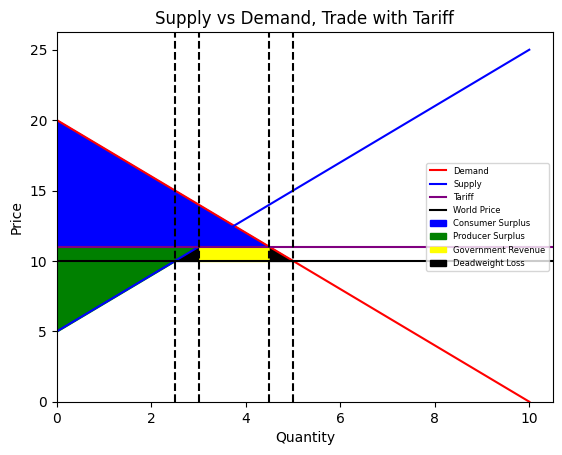

In [3]:
# Range of x, Slope of Supply Function, Slope of Demand Function, Intercept of Supply Function, Intercept of Demand Function
graph(10, 2, -2, 5, 20, False, False, 10, 11)